# Step 06: OpenSearch Hybrid Search 실험 및 평가

**목표**: OpenSearch 네이티브 Hybrid Search (BM25 + kNN)를 실험하고, 기존 FAISS와 RAGAS로 비교 평가

**비교 대상**:
| Retriever | 설명 |
|-----------|------|
| FAISS only | 기존 벡터 검색 (baseline) |
| BM25+FAISS (50/50) | step_05에서 최적화된 앙상블 |
| OpenSearch Hybrid | BM25(Nori) + kNN 네이티브 하이브리드 |

**사전 조건**: `docker-compose up opensearch -d` 실행 완료

---

## 1. 환경 설정

In [1]:
# 임포트 및 경로 설정
import os
import sys
import json
import time
import numpy as np
from pathlib import Path

# 프로젝트 루트 설정
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

# Windows 환경 호환성
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"프로젝트 루트: {project_root}")
print("임포트 완료!")

프로젝트 루트: C:\workspace\hr-agent
임포트 완료!


In [3]:
# OpenSearch 연결 확인
from opensearchpy import OpenSearch

opensearch_url = os.getenv("OPENSEARCH_URL", "http://localhost:9200")
client = OpenSearch(
    hosts=[opensearch_url],
    use_ssl=False,
    verify_certs=False,
)

info = client.info()
print(f"OpenSearch 버전: {info['version']['number']}")
print(f"클러스터 이름: {info['cluster_name']}")

# Nori 플러그인 확인
plugins = client.cat.plugins(format="json")
nori_found = any("analysis-nori" in p.get("component", "") for p in plugins)
print(f"Nori 플러그인: {'확인됨' if nori_found else '미설치 - 확인 필요'}")

OpenSearch 버전: 3.5.0
클러스터 이름: docker-cluster
Nori 플러그인: 확인됨


---
## 2. OpenSearch 인덱스 생성

- `content`: text 타입, Nori 한국어 분석기 (BM25용)
- `content_embedding`: knn_vector 1024차원, cosine similarity (kNN용)
- `metadata`: source, page, chunk_id

In [4]:
# 인덱스 설정
INDEX_NAME = "hr_documents"

index_body = {
    "settings": {
        "analysis": {
            "analyzer": {
                "nori_analyzer": {
                    "type": "custom",
                    "tokenizer": "nori_tokenizer"
                }
            }
        },
        "index.knn": True
    },
    "mappings": {
        "properties": {
            "content": {
                "type": "text",
                "analyzer": "nori_analyzer"
            },
            "content_embedding": {
                "type": "knn_vector",
                "dimension": 1024,
                "method": {
                    "name": "hnsw",
                    "space_type": "cosinesimil",
                    "engine": "lucene"
                }
            },
            "metadata": {
                "properties": {
                    "source": {"type": "keyword"},
                    "page": {"type": "integer"},
                    "chunk_id": {"type": "keyword"}
                }
            }
        }
    }
}

# 기존 인덱스 삭제 후 재생성
if client.indices.exists(index=INDEX_NAME):
    client.indices.delete(index=INDEX_NAME)
    print(f"기존 인덱스 '{INDEX_NAME}' 삭제")

client.indices.create(index=INDEX_NAME, body=index_body)
print(f"인덱스 '{INDEX_NAME}' 생성 완료")

# 매핑 확인
mapping = client.indices.get_mapping(index=INDEX_NAME)
props = mapping[INDEX_NAME]["mappings"]["properties"]
print(f"\n필드 목록:")
for field, config in props.items():
    field_type = config.get("type", "object")
    print(f"  {field}: {field_type}")

인덱스 'hr_documents' 생성 완료

필드 목록:
  content: text
  content_embedding: knn_vector
  metadata: object


---
## 3. 데이터 적재 (기존 FAISS 문서 + 임베딩 재사용)

In [7]:
# 임베딩 모델 초기화 (기존과 동일)
from core.llm.factory import create_embeddings

embeddings = create_embeddings(
    provider="huggingface",
    model="dragonkue/snowflake-arctic-embed-l-v2.0-ko"
)

print("임베딩 모델 초기화 완료!")

임베딩 모델 초기화 완료!


In [8]:
# 기존 FAISS 인덱스에서 문서 추출
from langchain_community.vectorstores import FAISS

index_path = project_root / "data/faiss_index"
vectorstore = FAISS.load_local(
    str(index_path),
    embeddings,
    allow_dangerous_deserialization=True
)

docstore = vectorstore.docstore
doc_ids = list(vectorstore.index_to_docstore_id.values())
documents = [docstore.search(doc_id) for doc_id in doc_ids]

print(f"FAISS에서 추출된 문서 수: {len(documents)}")
print(f"첫 번째 문서 미리보기: {documents[0].page_content[:80]}...")

FAISS에서 추출된 문서 수: 54
첫 번째 문서 미리보기: ## 서문: 용어 정의
본 규정에서 사용하는 주요 용어의 정의는 다음과 같다.
### 고용 및 인사 관련 용어
| 용어 | 정의 |
|-----...


In [9]:
# OpenSearch에 문서 + 임베딩 bulk 인덱싱
from opensearchpy.helpers import bulk

actions = []
print("임베딩 생성 및 인덱싱 준비 중...")

for i, doc in enumerate(documents):
    # 임베딩 생성
    vector = embeddings.embed_query(doc.page_content)
    
    # 메타데이터 준비
    metadata = doc.metadata if doc.metadata else {}
    
    action = {
        "_index": INDEX_NAME,
        "_id": i,
        "_source": {
            "content": doc.page_content,
            "content_embedding": vector,
            "metadata": {
                "source": metadata.get("source", ""),
                "page": metadata.get("page", 0),
                "chunk_id": f"chunk_{i}"
            }
        }
    }
    actions.append(action)
    
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(documents)} 준비 완료")

# Bulk 인덱싱
success, errors = bulk(client, actions)
print(f"\nBulk 인덱싱 완료: {success}개 성공, {len(errors) if isinstance(errors, list) else 0}개 실패")

# 인덱스 리프레시
client.indices.refresh(index=INDEX_NAME)

# 문서 수 확인
count = client.count(index=INDEX_NAME)
print(f"인덱싱된 문서 수: {count['count']}")

임베딩 생성 및 인덱싱 준비 중...
  10/54 준비 완료
  20/54 준비 완료
  30/54 준비 완료
  40/54 준비 완료
  50/54 준비 완료

Bulk 인덱싱 완료: 54개 성공, 0개 실패
인덱싱된 문서 수: 54


---
## 4. Search Pipeline 생성

BM25와 kNN 점수를 정규화하고 가중 평균으로 결합하는 파이프라인

In [10]:
# Search Pipeline 생성 (BM25 50% + kNN 50% 기본)
PIPELINE_NAME = "hr-hybrid-pipeline"

pipeline_body = {
    "description": "HR hybrid search pipeline (BM25 + kNN)",
    "phase_results_processors": [
        {
            "normalization-processor": {
                "normalization": {"technique": "min_max"},
                "combination": {
                    "technique": "arithmetic_mean",
                    "parameters": {"weights": [0.5, 0.5]}
                }
            }
        }
    ]
}

client.transport.perform_request(
    "PUT",
    f"/_search/pipeline/{PIPELINE_NAME}",
    body=pipeline_body
)
print(f"Search Pipeline '{PIPELINE_NAME}' 생성 완료")
print(f"  정규화: min_max")
print(f"  결합: arithmetic_mean (BM25 50% + kNN 50%)")

Search Pipeline 'hr-hybrid-pipeline' 생성 완료
  정규화: min_max
  결합: arithmetic_mean (BM25 50% + kNN 50%)


---
## 5. Hybrid Search 테스트

In [11]:
# OpenSearch Hybrid Search 함수
def opensearch_hybrid_search(query, k=5, pipeline_name=PIPELINE_NAME):
    """OpenSearch 네이티브 Hybrid Search (BM25 + kNN)"""
    query_embedding = embeddings.embed_query(query)
    
    body = {
        "size": k,
        "query": {
            "hybrid": {
                "queries": [
                    {"match": {"content": {"query": query}}},
                    {"knn": {"content_embedding": {"vector": query_embedding, "k": k}}}
                ]
            }
        }
    }
    
    response = client.search(
        index=INDEX_NAME,
        body=body,
        params={"search_pipeline": pipeline_name}
    )
    
    return response["hits"]["hits"]

print("Hybrid Search 함수 정의 완료")

Hybrid Search 함수 정의 완료


In [13]:
# 샘플 쿼리 테스트
test_queries = [
    "연차 휴가 며칠?",
    "병가 사용 방법",
    "퇴직금 계산",
]

for query in test_queries:
    print(f"\n쿼리: '{query}'")
    print("-" * 60)
    results = opensearch_hybrid_search(query, k=3)
    for i, hit in enumerate(results, 1):
        score = hit["_score"]
        content = hit["_source"]["content"][:100]
        print(f"  [{i}] ({score:.4f}) {content}...")


쿼리: '연차 휴가 며칠?'
------------------------------------------------------------
  [1] (1.0000) • 사례 5: E 직원이 연락 없이 2 일 연속 결근한 경우 → 서면 경위서 제출 요구, 미제출
시 추가 징계 검토
**제12 조 연차·병가·특별휴가의 수칙**
연차는 입사 첫해 ...
  [2] (0.2423) ② 계약직 연차: 계약직은 계약 기간에 비례하여 연차를 부여한다. 1 년 미만 계약 시 월
1 일씩 부여하며, 계약 종료 시 미사용분은 수당으로 정산한다.
③ 인턴 휴가: 인턴은 ...
  [3] (0.1169) A. 코어타임(10:00~16:00) 중에는 업무에 집중해야 하며, 외출 시 사전에 직속상관에게
보고해야 합니다. 코어타임 외 시간에는 업무 수행에 지장이 없는 범위 내에서 자율적...

쿼리: '병가 사용 방법'
------------------------------------------------------------
  [1] (1.0000) • 사례 5: E 직원이 연락 없이 2 일 연속 결근한 경우 → 서면 경위서 제출 요구, 미제출
시 추가 징계 검토
**제12 조 연차·병가·특별휴가의 수칙**
연차는 입사 첫해 ...
  [2] (0.3413) A. 코어타임(10:00~16:00) 중에는 업무에 집중해야 하며, 외출 시 사전에 직속상관에게
보고해야 합니다. 코어타임 외 시간에는 업무 수행에 지장이 없는 범위 내에서 자율적...
  [3] (0.0005) **제17 조 복리후생 비용 집행 및 관리 기준**
모든 복지 비용은 분기별로 사용 결과를 보고하며, 부서별 복지예산 집행률이 80% 미만일
경우 다음 분기 예산이 10% 자동 삭...

쿼리: '퇴직금 계산'
------------------------------------------------------------
  [1] (1.0000) ## 8. 징계 규정
### 8.1 징계 종류
- 경고: 서면 경고
- 감

---
## 6. RAGAS 평가 — 3가지 Retriever 비교

| Retriever | 설명 |
|-----------|------|
| FAISS only | step_05 baseline |
| BM25+FAISS (50/50) | step_05 최적 앙상블 |
| OpenSearch Hybrid | 이번 실험 |

In [14]:
# 테스트 데이터 로드
test_data_path = project_root / "data/finetuning/rag_test_50.json"

with open(test_data_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

questions = [item["question"] for item in test_data]
ground_truths = [item["ground_truth"] for item in test_data]

print(f"테스트 데이터 로드 완료: {len(test_data)} 샘플")

테스트 데이터 로드 완료: 50 샘플


In [15]:
# 검색 결과 수집 함수
def get_contexts_faiss(retriever, queries, k=5):
    """FAISS/Ensemble retriever로 context 수집"""
    all_contexts = []
    for query in queries:
        results = retriever.invoke(query)
        contexts = [doc.page_content for doc in results[:k]]
        all_contexts.append(contexts)
    return all_contexts

def get_contexts_opensearch(queries, k=5, pipeline_name=PIPELINE_NAME):
    """OpenSearch hybrid search로 context 수집"""
    all_contexts = []
    for query in queries:
        hits = opensearch_hybrid_search(query, k=k, pipeline_name=pipeline_name)
        contexts = [hit["_source"]["content"] for hit in hits]
        all_contexts.append(contexts)
    return all_contexts

print("검색 함수 정의 완료")

검색 함수 정의 완료


In [16]:
# 1) FAISS only 검색
print("[1/3] FAISS only 검색 중...")
faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
faiss_contexts = get_contexts_faiss(faiss_retriever, questions, k=5)
print(f"  완료: {len(faiss_contexts)} 쿼리")

# 2) BM25+FAISS Ensemble 검색 (step_05 최적 가중치 50/50)
print("[2/3] BM25+FAISS Ensemble 검색 중...")
from langchain.retrievers import EnsembleRetriever
from core.retrieval.korean_bm25 import create_korean_bm25_retriever

bm25_retriever = create_korean_bm25_retriever(documents, k=10)
faiss_retriever_10 = vectorstore.as_retriever(search_kwargs={"k": 10})
ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, faiss_retriever_10],
    weights=[0.5, 0.5]
)
ensemble_contexts = get_contexts_faiss(ensemble_retriever, questions, k=5)
print(f"  완료: {len(ensemble_contexts)} 쿼리")

# 3) OpenSearch Hybrid 검색
print("[3/3] OpenSearch Hybrid 검색 중...")
opensearch_contexts = get_contexts_opensearch(questions, k=5)
print(f"  완료: {len(opensearch_contexts)} 쿼리")

print("\n모든 검색 완료!")

[1/3] FAISS only 검색 중...
  완료: 50 쿼리
[2/3] BM25+FAISS Ensemble 검색 중...
  완료: 50 쿼리
[3/3] OpenSearch Hybrid 검색 중...
  완료: 50 쿼리

모든 검색 완료!


In [17]:
# RAGAS 평가 설정
from ragas import evaluate
from ragas.metrics import ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

from langchain_openai import ChatOpenAI, OpenAIEmbeddings

eval_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))
eval_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))

metrics = [
    ContextPrecision(llm=eval_llm),
    ContextRecall(llm=eval_llm),
]

print("RAGAS 평가 설정 완료")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43356\3303924340.py:3: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import ContextPrecision, ContextRecall
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43356\3303924340.py:3: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextRecall
  from ragas.metrics import ContextPrecision, ContextRecall
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43356\3303924340.py:10: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('

RAGAS 평가 설정 완료


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_43356\3303924340.py:11: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  eval_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))


In [18]:
%%time
# 1) FAISS only 평가
print("[1/3] FAISS only 평가 중...")
faiss_dataset = Dataset.from_dict({
    "question": questions,
    "contexts": faiss_contexts,
    "ground_truth": ground_truths,
})
faiss_results = evaluate(dataset=faiss_dataset, metrics=metrics)

faiss_cp = np.mean(faiss_results['context_precision'])
faiss_cr = np.mean(faiss_results['context_recall'])
print(f"  Precision: {faiss_cp:.4f}, Recall: {faiss_cr:.4f}")

[1/3] FAISS only 평가 중...


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:28<00:00,  3.89s/it]


  Precision: 0.8427, Recall: 0.9500
CPU times: total: 3min 20s
Wall time: 6min 30s


In [19]:
%%time
# 2) BM25+FAISS Ensemble 평가
print("[2/3] BM25+FAISS Ensemble 평가 중...")
ensemble_dataset = Dataset.from_dict({
    "question": questions,
    "contexts": ensemble_contexts,
    "ground_truth": ground_truths,
})
ensemble_results = evaluate(dataset=ensemble_dataset, metrics=metrics)

ensemble_cp = np.mean(ensemble_results['context_precision'])
ensemble_cr = np.mean(ensemble_results['context_recall'])
print(f"  Precision: {ensemble_cp:.4f}, Recall: {ensemble_cr:.4f}")

[2/3] BM25+FAISS Ensemble 평가 중...


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:33<00:00,  3.94s/it]


  Precision: 0.8717, Recall: 0.9800
CPU times: total: 3min 22s
Wall time: 6min 35s


In [20]:
%%time
# 3) OpenSearch Hybrid 평가
print("[3/3] OpenSearch Hybrid 평가 중...")
opensearch_dataset = Dataset.from_dict({
    "question": questions,
    "contexts": opensearch_contexts,
    "ground_truth": ground_truths,
})
opensearch_results = evaluate(dataset=opensearch_dataset, metrics=metrics)

opensearch_cp = np.mean(opensearch_results['context_precision'])
opensearch_cr = np.mean(opensearch_results['context_recall'])
print(f"  Precision: {opensearch_cp:.4f}, Recall: {opensearch_cr:.4f}")

[3/3] OpenSearch Hybrid 평가 중...


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:46<00:00,  4.07s/it]


  Precision: 0.8592, Recall: 0.9800
CPU times: total: 3min 24s
Wall time: 6min 48s


In [21]:
# 3가지 Retriever 비교 테이블
print("=" * 70)
print("3가지 Retriever 비교 (RAGAS 평가)")
print("=" * 70)

results_table = [
    ("FAISS only", faiss_cp, faiss_cr),
    ("BM25+FAISS (50/50)", ensemble_cp, ensemble_cr),
    ("OpenSearch Hybrid", opensearch_cp, opensearch_cr),
]

print(f"{'Retriever':<25} {'Precision':<12} {'Recall':<12} {'Average':<12}")
print("-" * 70)
for name, cp, cr in results_table:
    avg = (cp + cr) / 2
    print(f"{name:<25} {cp:<12.4f} {cr:<12.4f} {avg:<12.4f}")

print("-" * 70)

# FAISS 대비 변화량
faiss_avg = (faiss_cp + faiss_cr) / 2
ensemble_avg = (ensemble_cp + ensemble_cr) / 2
opensearch_avg = (opensearch_cp + opensearch_cr) / 2

print(f"\nFAISS 대비 변화:")
print(f"  BM25+FAISS:      {ensemble_avg - faiss_avg:+.4f} ({(ensemble_avg - faiss_avg) / faiss_avg * 100:+.1f}%)")
print(f"  OpenSearch:      {opensearch_avg - faiss_avg:+.4f} ({(opensearch_avg - faiss_avg) / faiss_avg * 100:+.1f}%)")

print(f"\nBM25+FAISS 대비 OpenSearch 변화:")
print(f"  {opensearch_avg - ensemble_avg:+.4f} ({(opensearch_avg - ensemble_avg) / ensemble_avg * 100:+.1f}%)")

3가지 Retriever 비교 (RAGAS 평가)
Retriever                 Precision    Recall       Average     
----------------------------------------------------------------------
FAISS only                0.8427       0.9500       0.8964      
BM25+FAISS (50/50)        0.8717       0.9800       0.9259      
OpenSearch Hybrid         0.8592       0.9800       0.9196      
----------------------------------------------------------------------

FAISS 대비 변화:
  BM25+FAISS:      +0.0295 (+3.3%)
  OpenSearch:      +0.0232 (+2.6%)

BM25+FAISS 대비 OpenSearch 변화:
  -0.0063 (-0.7%)


---
## 6-1. RRF (Reciprocal Rank Fusion) 비교 실험

Weighted Sum(점수 기반)과 RRF(순위 기반)를 비교합니다.

| 방식 | 프로세서 | 원리 |
|------|---------|------|
| Weighted Sum | `normalization-processor` | min_max 정규화 → 가중 평균 |
| RRF | `score-ranker-processor` | 순위 기반 융합 `1/(k+rank)` |

In [ ]:
# RRF Search Pipeline 생성 (score-ranker-processor)
RRF_PIPELINE_NAME = "hr-rrf-pipeline"

rrf_pipeline_body = {
    "description": "HR hybrid search pipeline (RRF)",
    "phase_results_processors": [
        {
            "score-ranker-processor": {
                "combination": {
                    "technique": "rrf",
                    "rank_constant": 60  # 기본값
                }
            }
        }
    ]
}

client.transport.perform_request(
    "PUT",
    f"/_search/pipeline/{RRF_PIPELINE_NAME}",
    body=rrf_pipeline_body
)
print(f"RRF Pipeline '{RRF_PIPELINE_NAME}' 생성 완료")
print(f"  방식: Reciprocal Rank Fusion")
print(f"  rank_constant: 60 (기본값)")
print()
print("[Weighted Sum vs RRF 코드 비교]")
print("  Weighted Sum: normalization-processor → min_max → arithmetic_mean(weights)")
print("  RRF:          score-ranker-processor → rrf(rank_constant=60)")

In [ ]:
%%time
# RRF Hybrid Search로 검색 + RAGAS 평가
print("[RRF] OpenSearch RRF Hybrid 검색 중...")
rrf_contexts = get_contexts_opensearch(questions, k=5, pipeline_name=RRF_PIPELINE_NAME)
print(f"  검색 완료: {len(rrf_contexts)} 쿼리")

print("[RRF] RAGAS 평가 중...")
rrf_dataset = Dataset.from_dict({
    "question": questions,
    "contexts": rrf_contexts,
    "ground_truth": ground_truths,
})
rrf_results = evaluate(dataset=rrf_dataset, metrics=metrics)

rrf_cp = np.mean(rrf_results["context_precision"])
rrf_cr = np.mean(rrf_results["context_recall"])
rrf_avg = (rrf_cp + rrf_cr) / 2
print(f"  Precision: {rrf_cp:.4f}, Recall: {rrf_cr:.4f}, Average: {rrf_avg:.4f}")

In [ ]:
# Weighted Sum vs RRF 비교
print("=" * 70)
print("Weighted Sum vs RRF 비교")
print("=" * 70)
print(f"{"Method":<30} {"Precision":<12} {"Recall":<12} {"Average":<12}")
print("-" * 70)
print(f"{"OpenSearch Weighted (50/50)":<30} {opensearch_cp:<12.4f} {opensearch_cr:<12.4f} {opensearch_avg:<12.4f}")
print(f"{"OpenSearch RRF (k=60)":<30} {rrf_cp:<12.4f} {rrf_cr:<12.4f} {rrf_avg:<12.4f}")
print("-" * 70)
diff = rrf_avg - opensearch_avg
print(f"
RRF vs Weighted Sum 차이: {diff:+.4f} ({diff / opensearch_avg * 100:+.1f}%)")
print()
if rrf_avg > opensearch_avg:
    print("→ RRF가 더 높음. Grid Search에서 RRF도 함께 비교 권장")
else:
    print("→ Weighted Sum이 더 높음. 가중치 튜닝이 유효한 전략")

---
## 7. OpenSearch 가중치 Grid Search

BM25/kNN 가중치를 0.0~1.0으로 변경하며 최적 비율 탐색

In [22]:
# 가중치별 search pipeline 생성 함수
def create_pipeline(bm25_weight, knn_weight, pipeline_name):
    """가중치를 적용한 search pipeline 생성"""
    body = {
        "description": f"HR hybrid pipeline (BM25={bm25_weight}, kNN={knn_weight})",
        "phase_results_processors": [
            {
                "normalization-processor": {
                    "normalization": {"technique": "min_max"},
                    "combination": {
                        "technique": "arithmetic_mean",
                        "parameters": {"weights": [bm25_weight, knn_weight]}
                    }
                }
            }
        ]
    }
    client.transport.perform_request("PUT", f"/_search/pipeline/{pipeline_name}", body=body)

print("Pipeline 생성 함수 정의 완료")

Pipeline 생성 함수 정의 완료


In [23]:
%%time
# Grid Search 실행
weight_configs = [
    (0.0, 1.0),  # kNN only
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),  # 균등
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
    (1.0, 0.0),  # BM25 only
]

grid_results = []

for bm25_w, knn_w in weight_configs:
    pipeline_name = f"hr-grid-{int(bm25_w*10)}-{int(knn_w*10)}"
    print(f"\n테스트: BM25={bm25_w:.0%}, kNN={knn_w:.0%}")
    
    # Pipeline 생성
    create_pipeline(bm25_w, knn_w, pipeline_name)
    
    # 검색
    contexts = get_contexts_opensearch(questions, k=5, pipeline_name=pipeline_name)
    
    # RAGAS 평가
    dataset = Dataset.from_dict({
        "question": questions,
        "contexts": contexts,
        "ground_truth": ground_truths,
    })
    result = evaluate(dataset=dataset, metrics=metrics)
    
    cp = np.mean(result['context_precision'])
    cr = np.mean(result['context_recall'])
    avg = (cp + cr) / 2
    
    grid_results.append({
        "bm25_weight": bm25_w,
        "knn_weight": knn_w,
        "context_precision": float(cp),
        "context_recall": float(cr),
        "avg_score": float(avg),
    })
    
    print(f"  CP={cp:.4f}, CR={cr:.4f}, Avg={avg:.4f}")

print("\nGrid Search 완료!")


테스트: BM25=0%, kNN=100%


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:39<00:00,  3.99s/it]


  CP=0.8405, CR=0.9500, Avg=0.8952

테스트: BM25=10%, kNN=90%


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:43<00:00,  4.03s/it]


  CP=0.8493, CR=0.9700, Avg=0.9097

테스트: BM25=20%, kNN=80%


...

  CP=0.8192, CR=0.9800, Avg=0.8996

테스트: BM25=90%, kNN=10%


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:36<00:00,  3.96s/it]


  CP=0.8264, CR=0.9900, Avg=0.9082

테스트: BM25=100%, kNN=0%


Evaluating: 100%|████████████████████████████████████████████████████████████████| 100/100 [06:53<00:00,  4.13s/it]


  CP=0.8203, CR=0.9700, Avg=0.8952

Grid Search 완료!
CPU times: total: 44min 21s
Wall time: 1h 15min 59s


In [24]:
# Grid Search 결과 테이블
import pandas as pd

df = pd.DataFrame(grid_results)
df = df.sort_values("avg_score", ascending=False)

print("=" * 70)
print("OpenSearch Grid Search 결과 (평균 점수 순)")
print("=" * 70)
print(df.to_string(index=False))

best = df.iloc[0]
print(f"\n최적 설정:")
print(f"  BM25: {best['bm25_weight']:.0%}")
print(f"  kNN: {best['knn_weight']:.0%}")
print(f"  평균 점수: {best['avg_score']:.4f}")

OpenSearch Grid Search 결과 (평균 점수 순)
 bm25_weight  knn_weight  context_precision  context_recall  avg_score
         0.6         0.4           0.839194            0.99   0.914597
         0.4         0.6           0.847583            0.98   0.913792
         0.3         0.7           0.846694            0.98   0.913347
         0.7         0.3           0.823417            1.00   0.911708
         0.5         0.5           0.852500            0.97   0.911250
         0.2         0.8           0.840333            0.98   0.910167
         0.1         0.9           0.849333            0.97   0.909667
         0.9         0.1           0.826444            0.99   0.908222
         0.8         0.2           0.819194            0.98   0.899597
         0.0         1.0           0.840500            0.95   0.895250
         1.0         0.0           0.820306            0.97   0.895153

최적 설정:
  BM25: 60%
  kNN: 40%
  평균 점수: 0.9146


---
## 8. 시각화

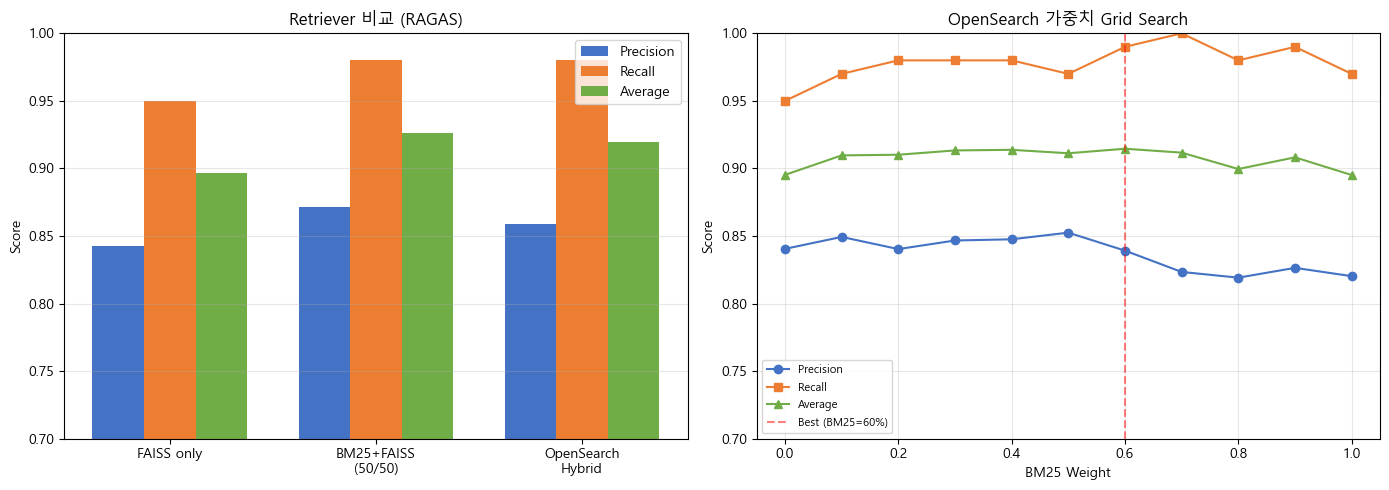

차트 저장 완료


In [25]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 3가지 Retriever 비교 바 차트
ax1 = axes[0]
retrievers = ["FAISS only", "BM25+FAISS\n(50/50)", "OpenSearch\nHybrid"]
precisions = [faiss_cp, ensemble_cp, opensearch_cp]
recalls = [faiss_cr, ensemble_cr, opensearch_cr]
avgs = [faiss_avg, ensemble_avg, opensearch_avg]

x = np.arange(len(retrievers))
width = 0.25

bars1 = ax1.bar(x - width, precisions, width, label='Precision', color='#4472C4')
bars2 = ax1.bar(x, recalls, width, label='Recall', color='#ED7D31')
bars3 = ax1.bar(x + width, avgs, width, label='Average', color='#70AD47')

ax1.set_ylabel('Score')
ax1.set_title('Retriever 비교 (RAGAS)')
ax1.set_xticks(x)
ax1.set_xticklabels(retrievers)
ax1.legend()
ax1.set_ylim(0.7, 1.0)
ax1.grid(axis='y', alpha=0.3)

# 2) OpenSearch Grid Search 결과 선 그래프
ax2 = axes[1]
df_sorted = pd.DataFrame(grid_results).sort_values("bm25_weight")

ax2.plot(df_sorted['bm25_weight'], df_sorted['context_precision'], 'o-', label='Precision', color='#4472C4')
ax2.plot(df_sorted['bm25_weight'], df_sorted['context_recall'], 's-', label='Recall', color='#ED7D31')
ax2.plot(df_sorted['bm25_weight'], df_sorted['avg_score'], '^-', label='Average', color='#70AD47')

# 최적점 표시
ax2.axvline(x=best['bm25_weight'], color='red', linestyle='--', alpha=0.5, label=f'Best (BM25={best["bm25_weight"]:.0%})')

ax2.set_xlabel('BM25 Weight')
ax2.set_ylabel('Score')
ax2.set_title('OpenSearch 가중치 Grid Search')
ax2.legend(fontsize=8)
ax2.set_ylim(0.7, 1.0)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(project_root / "data/finetuning/opensearch_evaluation_chart.png"), dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장 완료")

---
## 9. 결과 저장

In [26]:
# 전체 결과 JSON 저장
evaluation_results = {
    "comparison": {
        "faiss_only": {
            "context_precision": float(faiss_cp),
            "context_recall": float(faiss_cr),
            "avg_score": float(faiss_avg),
        },
        "bm25_faiss_ensemble": {
            "bm25_weight": 0.5,
            "faiss_weight": 0.5,
            "context_precision": float(ensemble_cp),
            "context_recall": float(ensemble_cr),
            "avg_score": float(ensemble_avg),
        },
        "opensearch_hybrid": {
            "bm25_weight": 0.5,
            "knn_weight": 0.5,
            "context_precision": float(opensearch_cp),
            "context_recall": float(opensearch_cr),
            "avg_score": float(opensearch_avg),
        },
    },
    "opensearch_grid_search": {
        "best": {
            "bm25_weight": float(best['bm25_weight']),
            "knn_weight": float(best['knn_weight']),
            "context_precision": float(best['context_precision']),
            "context_recall": float(best['context_recall']),
            "avg_score": float(best['avg_score']),
        },
        "all_results": grid_results,
    },
    "config": {
        "embedding_model": "dragonkue/snowflake-arctic-embed-l-v2.0-ko",
        "embedding_dim": 1024,
        "chunk_size": 1500,
        "chunk_overlap": 300,
        "test_samples": len(test_data),
        "opensearch_version": info['version']['number'],
        "index_name": INDEX_NAME,
    },
}

result_path = project_root / "data/finetuning/opensearch_evaluation_results.json"
with open(result_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print(f"평가 결과 저장 완료: {result_path}")

평가 결과 저장 완료: C:\workspace\hr-agent\data\finetuning\opensearch_evaluation_results.json


---
## 10. 결과 요약

In [27]:
# 최종 결과 요약
print("=" * 70)
print("OpenSearch Hybrid Search 실험 결과 요약")
print("=" * 70)

print(f"\n[3가지 Retriever 비교]")
print(f"{'Retriever':<25} {'Precision':<12} {'Recall':<12} {'Average':<12}")
print("-" * 60)
for name, cp, cr in results_table:
    avg = (cp + cr) / 2
    print(f"{name:<25} {cp:<12.4f} {cr:<12.4f} {avg:<12.4f}")

print(f"\n[OpenSearch 최적 가중치]")
print(f"  BM25: {best['bm25_weight']:.0%}")
print(f"  kNN: {best['knn_weight']:.0%}")
print(f"  최적 Average: {best['avg_score']:.4f}")

print(f"\n[마이그레이션 판단]")
bm25_faiss_best = 0.9292  # step_05 결과
if best['avg_score'] >= bm25_faiss_best:
    print(f"  OpenSearch ({best['avg_score']:.4f}) >= BM25+FAISS ({bm25_faiss_best:.4f})")
    print(f"  → 프로덕션 마이그레이션 진행 가능")
else:
    print(f"  OpenSearch ({best['avg_score']:.4f}) < BM25+FAISS ({bm25_faiss_best:.4f})")
    print(f"  → 가중치 추가 실험 또는 다른 최적화 필요")

print(f"\n[다음 단계]")
print("  1. OpenSearch >= BM25+FAISS 확인 시 → Phase B (프로덕션 마이그레이션)")
print("  2. core/retrieval/opensearch_retriever.py 모듈화")
print("  3. scripts/build_opensearch_index.py CLI 스크립트")
print("  4. core/agents/rag_agent.py에 retriever_type 추가")

OpenSearch Hybrid Search 실험 결과 요약

[3가지 Retriever 비교]
Retriever                 Precision    Recall       Average     
------------------------------------------------------------
FAISS only                0.8427       0.9500       0.8964      
BM25+FAISS (50/50)        0.8717       0.9800       0.9259      
OpenSearch Hybrid         0.8592       0.9800       0.9196      

[OpenSearch 최적 가중치]
  BM25: 60%
  kNN: 40%
  최적 Average: 0.9146

[마이그레이션 판단]
  OpenSearch (0.9146) < BM25+FAISS (0.9292)
  → 가중치 추가 실험 또는 다른 최적화 필요

[다음 단계]
  1. OpenSearch >= BM25+FAISS 확인 시 → Phase B (프로덕션 마이그레이션)
  2. core/retrieval/opensearch_retriever.py 모듈화
  3. scripts/build_opensearch_index.py CLI 스크립트
  4. core/agents/rag_agent.py에 retriever_type 추가


---
## 완료

OpenSearch Hybrid Search 실험 및 RAGAS 평가가 완료되었습니다.

### 실험 내용
- OpenSearch Docker 연결 + Nori 한국어 분석기 확인
- `hr_documents` 인덱스 생성 (Nori + knn_vector 1024d)
- 기존 FAISS 문서를 OpenSearch에 bulk 인덱싱
- Search Pipeline (BM25 + kNN 점수 정규화/결합)
- RAGAS 평가: FAISS vs BM25+FAISS vs OpenSearch Hybrid
- 가중치 Grid Search (BM25/kNN 비율 최적화)

### 다음 단계
- 평가 결과 확인 → OpenSearch가 동등 이상이면 Phase B 진행
- Phase B: 프로덕션 마이그레이션 (retriever 모듈화, RAG Agent 통합)